Gameplay:
- 5 x 5 grid
- two players are initialized at random positions on the grid
- one player can move, the other is stationary
- goal -> move player one to player two in the least number of steps possible

- Observation -> (player_1_row, player_1_col, player_2_row, player_2_col)
- action -> (0 for up, 1 for right, 2 for down, 3 for left)
- Reward -> -1 for every step, + 10 for catching a player

In [1]:
import numpy as np
import torch.nn as nn
import torch
import random
from tqdm import trange
import matplotlib.pyplot as plt
from scipy.signal import convolve
from scipy.signal.windows import gaussian
from IPython.display import clear_output

In [44]:
class Env():
    def __init__(self, board_size: int, seed: int):
        np.random.default_rng(seed)
        self.board_size = board_size
        self.observation_space_shape = (4,)
        self.action_space_n = 4

        self.board = np.zeros((board_size, board_size), dtype=np.int32)

        self.p1_row, self.p1_col, self.p2_row, self.p2_col = -1, -1, -1, -1
        self._sample_positions()
        self.update_board()

    def _sample_positions(self):
        while self.p1_row == self.p2_row and self.p1_col == self.p2_col:
            self.p1_row, self.p1_col, self.p2_row, self.p2_col = np.random.randint(
                0, self.board_size, 4
            )

    def reset(self, seed: int = 123):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.p1_row, self.p1_col, self.p2_row, self.p2_col = -1, -1, -1, -1
        self._sample_positions()
        self.update_board()
        return self.get_pos()

    def get_pos(self):
        return self.p1_row, self.p1_col, self.p2_row, self.p2_col

    def update_board(self):
        self.board.fill(0)
        self.board[self.p1_row, self.p1_col] = 1
        self.board[self.p2_row, self.p2_col] = 2

    def show_board_pos(self):
        print(self.board)

    def limit_coordinates(self):
        """Keep player 1 inside the grid in (row, col) space."""
        self.p1_row = min(self.p1_row, self.board_size - 1)
        self.p1_row = max(self.p1_row, 0)
        self.p1_col = min(self.p1_col, self.board_size - 1)
        self.p1_col = max(self.p1_col, 0)
        return self.p1_row, self.p1_col

    def step(self, action: int):
        reward = -1
        terminated = False

        if action == 0:
            self.p1_row -= 1
        elif action == 1:
            self.p1_col += 1
        elif action == 2:
            self.p1_row += 1
        elif action == 3:
            self.p1_col -= 1
        else:
            raise ValueError(f"Invalid action: {action}")

        self.p1_row, self.p1_col = self.limit_coordinates()

        if self.p1_row == self.p2_row and self.p1_col == self.p2_col:
            reward += 10
            terminated = True

        self.update_board()
        return self.get_pos(), reward, terminated, False, {}

In [45]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [46]:
class DQNAgent(nn.Module):
    def __init__(self, state_shape, n_actions, epsilon = 0):
        super().__init__()
        
        self.epsilon = epsilon
        self.state_shape = state_shape
        self.n_actions = n_actions

        state_dim = self.state_shape[0]

        self.network = nn.Sequential()
        self.network.add_module('layer1', nn.Linear(state_dim, 256))
        self.network.add_module('relu1', nn.ReLU())
        self.network.add_module('layer2', nn.Linear(256, 256))
        self.network.add_module('relu2', nn.ReLU())
        self.network.add_module('layer3', nn.Linear(256, n_actions))
        self.parameters = self.network.parameters

    def forward(self, state_t):
        q_values = self.network(state_t)
        return q_values

    def get_qvalues(self, states):
        states = torch.tensor(np.array(states), device=device, dtype=torch.float32)
        qvalues = self.forward(states)
        return qvalues.data.cpu().numpy()

    def get_action(self, states):
        states = torch.tensor(np.array(states), device=device, dtype=torch.float32)
        qvalues = self.forward(states)
        best_actions = qvalues.argmax(axis=-1)
        return best_actions

    def sample_actions(self, qvalues):
        '''
        epsilon based sampling
        '''
        epsilon = self.epsilon
        batch_size, n_actions = qvalues.shape
        random_actions = np.random.choice(n_actions, size=batch_size)
        best_actions = qvalues.argmax(axis=-1)
        should_explore = np.random.choice([0, 1], batch_size, p=[1-epsilon, epsilon])
        
        return np.where(should_explore, random_actions, best_actions)

In [47]:
class ReplayBuffer:
    def __init__(self, size):
        self.size = size
        self.buffer = []
        self.next_id = 0
    
    def __len__(self):
        return len(self.buffer)
    
    def add(self, state, action, reward, next_state, done):
        item = (state, action, reward, next_state, done)
        if len(self.buffer) < self.size:
            self.buffer.append(item)
        else:
            self.buffer[self.next_id] = item
        self.next_id = (self.next_id + 1) % self.size
    
    def sample(self, batch_size):
        indexes = np.random.choice(len(self.buffer), batch_size)
        samples = [self.buffer[i] for i in indexes]
        states, actions, rewards, next_states, done_flags = list(zip(*samples))
        return np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(done_flags)

In [48]:
seed = 132
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [50]:
#setup env and agent and target networks
env = Env(board_size=6, seed=seed)
state_dim = env.observation_space_shape
n_actions = env.action_space_n
state = env.reset(seed=seed)

agent = DQNAgent(state_dim, n_actions, epsilon=1).to(device)
target_network = DQNAgent(state_dim, n_actions, epsilon=1).to(device)
target_network.load_state_dict(agent.state_dict())

<All keys matched successfully>

In [51]:
def play_and_record(start_state, agent: DQNAgent, env: Env, exp_replay: ReplayBuffer, n_steps=1):

    s = start_state
    sum_rewards = 0

    # Play the game for n_steps and record transitions in buffer
    for _ in range(n_steps):
        qvalues = agent.get_qvalues([s])
        a = agent.sample_actions(qvalues)[0]
        next_s, r, terminated, truncated, _ = env.step(a)
        sum_rewards += r
        done = terminated or truncated
        exp_replay.add(s, a, r, next_s, done)
        if done:
            s = env.reset()
        else:
            s = next_s

    return sum_rewards, s

In [52]:
exp_replay = ReplayBuffer(size=10**4)
for i in range(100):
    play_and_record(state, agent, env, exp_replay, n_steps=10**2)
    if len(exp_replay) == 10**4:
        break
print(len(exp_replay))

10000


In [53]:
def compute_td_loss(agent, target_network, states, actions, rewards, next_states, done_flags,
                    gamma=0.99, device=device):

    # convert numpy array to torch tensors
    states = torch.tensor(states, device=device, dtype=torch.float)
    actions = torch.tensor(actions, device=device, dtype=torch.long)
    rewards = torch.tensor(rewards, device=device, dtype=torch.float)
    next_states = torch.tensor(next_states, device=device, dtype=torch.float)
    done_flags = torch.tensor(done_flags.astype('float32'),device=device,dtype=torch.float)

    # get q-values for all actions in current states
    # use agent network
    predicted_qvalues = agent(states)

    # compute q-values for all actions in next states
    # use target network
    predicted_next_qvalues = target_network(next_states)

    # select q-values for chosen actions
    predicted_qvalues_for_actions = predicted_qvalues[range(len(actions)), actions]

    # compute Qmax(next_states, actions) using predicted next q-values
    next_state_values,_ = torch.max(predicted_next_qvalues, dim=1)

    # compute "target q-values"
    target_qvalues_for_actions = rewards + gamma * next_state_values * (1-done_flags)

    # mean squared error loss to minimize
    loss = torch.mean((predicted_qvalues_for_actions -
                       target_qvalues_for_actions.detach()) ** 2)

    return loss

In [54]:
def evaluate(env: Env, agent: DQNAgent, n_games=1, greedy=False, t_max=10000):
    rewards = []
    for _ in range(n_games):
        s = env.reset()
        reward = 0
        for _ in range(t_max):
            env.show_board_pos()
            qvalues = agent.get_qvalues([s])
            action = qvalues.argmax(axis=-1)[0] if greedy else agent.sample_actions(qvalues)[0]
            s, r, termiated, truncated,_ = env.step(action)
            reward += r
            if termiated:
                break

        rewards.append(reward)
    return np.mean(rewards)

In [55]:
#setup some parameters for training
timesteps_per_epoch = 1
batch_size = 32
total_steps = 10000

#init Optimizer
opt = torch.optim.Adam(agent.parameters(), lr=1e-4)

# set exploration epsilon
start_epsilon = 1
end_epsilon = 0.05
eps_decay_final_step = 2 * 10**4

# setup some frequency for logging and updating target network
loss_freq = 20
refresh_target_network_freq = 100
eval_freq = 1000

# to clip the gradients
max_grad_norm = 5000

In [56]:
mean_rw_history = []
td_loss_history = []

In [57]:
def epsilon_schedule(start_eps, end_eps, step, final_step):
    return start_eps + (end_eps-start_eps)*min(step, final_step)/final_step

def smoothen(values):
    kernel = gaussian(100, std=100)
    kernel = kernel / np.sum(kernel)
    return convolve(values, kernel, 'valid')

buffer size = 10000, epsilon = 0.52500


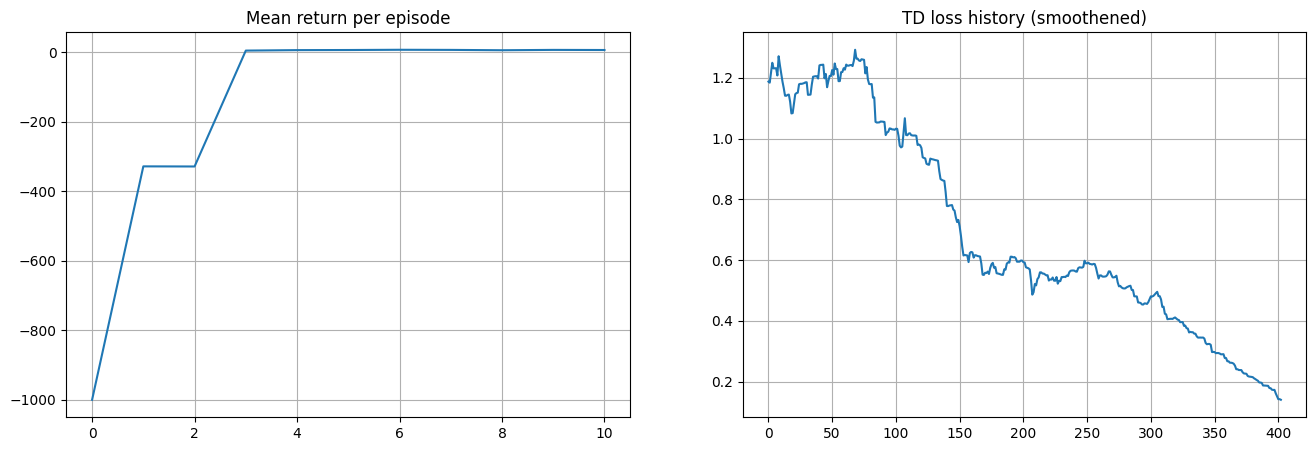

100%|██████████| 10001/10001 [00:51<00:00, 195.58it/s]


In [59]:
state = env.reset()

for step in trange(total_steps + 1):

    # reduce exploration as we progress
    agent.epsilon = epsilon_schedule(start_epsilon, end_epsilon, step, eps_decay_final_step)

    # take timesteps_per_epoch and update experience replay buffer
    _, state = play_and_record(state, agent, env, exp_replay, timesteps_per_epoch)

    # train by sampling batch_size of data from experience replay
    states, actions, rewards, next_states, done_flags = exp_replay.sample(batch_size)


    # loss = <compute TD loss>
    loss = compute_td_loss(agent, target_network,
                           states, actions, rewards, next_states, done_flags,
                           gamma=0.99,
                           device=device)

    loss.backward()
    grad_norm = nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
    opt.step()
    opt.zero_grad()

    if step % loss_freq == 0:
        td_loss_history.append(loss.data.cpu().item())

    if step % refresh_target_network_freq == 0:
        # Load agent weights into target_network
        target_network.load_state_dict(agent.state_dict())

    if step % eval_freq == 0:
        # eval the agent
        new_env = Env(board_size=6, seed=seed)
        mean_rw_history.append(evaluate(
            new_env, agent, n_games=3, greedy=True, t_max=1000)
        )

        clear_output(True)
        print("buffer size = %i, epsilon = %.5f" %
              (len(exp_replay), agent.epsilon))

        plt.figure(figsize=[16, 5])
        plt.subplot(1, 2, 1)
        plt.title("Mean return per episode")
        plt.plot(mean_rw_history)
        plt.grid()

        assert not np.isnan(td_loss_history[-1])
        plt.subplot(1, 2, 2)
        plt.title("TD loss history (smoothened)")
        plt.plot(smoothen(td_loss_history))
        plt.grid()

        plt.show()

In [65]:
final_score = evaluate(
  Env(board_size=6, seed=seed),
  agent, n_games=1, greedy=True, t_max=1000
)
print('final score:', final_score)
print('Well done')

[[0 0 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 0 0]
 [0 2 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
[[0 0 0 0 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 0]
 [0 2 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
[[0 0 0 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 0 0]
 [0 2 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 1 0 0]
 [0 2 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 2 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 2 1 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
final score: 4.0
Well done
